# CNN - 합성곱 신경망

In [1]:
import keras
import tensorflow as tf
from sklearn.model_selection import train_test_split

In [2]:
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

In [3]:
train_scaled = train_input.reshape(-1, 28, 28, 1) / 255.0
test_scaled = test_input.reshape(-1, 28, 28, 1) / 255.0

In [4]:
train_scaled.shape # 4차원
# 합성곱 Conv2D는 입력값으로 4차원 텐서를 요구
# 채널이 1(흑백)이라서 28 * 28 * 1 이지만, 컬러는 reshape(-1, H, W, 3) RGB 3채널
# 4차원 텐서 순서 (batch, H, W, Channel)

(60000, 28, 28, 1)

In [5]:
model = keras.Sequential() # 모델 구성

In [6]:
model.add(keras.layers.Input(shape=(28, 28 ,1))) # 입력층 4차원(배치는 생략)


In [7]:
# Layer 1
model.add(keras.layers.Conv2D(32, 3, activation='relu', padding='same')) # 필터 갯수를 32개, 3 * 3 필터, ReLu, 패딩 설정
# 출력 shape(28, 28, 32), 파라미터 수: (3 * 3 * 1 + 1) * 32 = 320
model.add(keras.layers.MaxPooling2D(2))
# 출력 shape(14, 14, 32), 파라미터 수 : 0

In [8]:
# Layer 2
model.add(keras.layers.Conv2D(64, 3, activation='relu', padding='same')) # 필터 갯수를 64개, 3 * 3 필터, ReLu, 패딩 설정
# 출력 shape(14, 14, 64), 파라미터 수: (3 * 3 * 32 + 1) * 64 = 18496
model.add(keras.layers.MaxPooling2D(2))
# 출력 shape(7, 7, 32), 파라미터 수 : 0

## 입력층과 출력층의 모양
### Input Shape: A 4D tensor with shape: (batch_size, height, width, channels)
### Output Shape: A 4D tensor with shape: (batch_size, new_height, new_width, filters)

## 다운 샘플링
연산량을 줄이고, 속도를 늘리고, 추상화를 개념화 시키기 위해, 해상도, 특징을 압축하고 요약하는 단계

In [ ]:
# Full-Connected Layer
model.add(keras.layers.Flatten())  # 출력 7 * 7 * 64 = 3136 (batch, 3136)
# flatten 층의 파라미터는 없음


In [10]:
model.add(keras.layers.Dense(100, activation='relu'))  # 파라미터 3136 * 100 + 100 = 313,700

In [11]:
model.add(keras.layers.Dropout(0.4)) # 과적합 피하기 위한 드롭아웃

In [12]:
# 출력층 : 구별하고자 하는 분류 갯수만큼(class) Unit 설정
model.add(keras.layers.Dense(10, activation='softmax')) # 파라미터 100 * 10 + 10 = 1010

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,526 (1.27 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# 모델 컴파일
model.compile(optimizer='adam', loss=keras.losses.sparse_categorical_crossentropy,
              metrics=['accuracy'], jit_compile=False)

In [15]:
# 콜백 설정 (checkpoint, early_stopping)
checkpoint = keras.callbacks.ModelCheckpoint('best-model.keras', save_best_only=True)
early_stopping = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)

In [18]:
history = model.fit(train_scaled, train_target, epochs=20, validation_split=0.2, callbacks=[checkpoint, early_stopping]) # 48000 : 12000(train, val)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9331 - loss: 0.1822 - val_accuracy: 0.9188 - val_loss: 0.2201
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9365 - loss: 0.1695 - val_accuracy: 0.9238 - val_loss: 0.2225


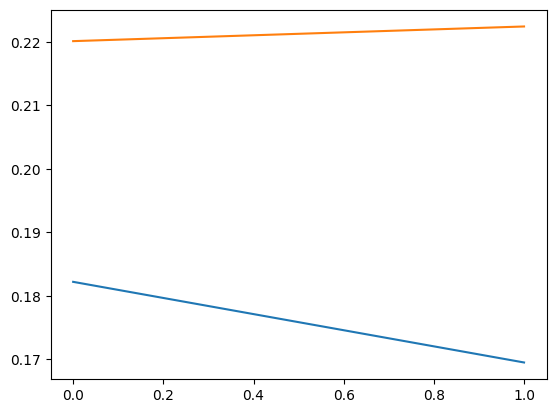

In [19]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])


In [20]:
# 검증 데이터 평가
model.evaluate(test_scaled, test_target)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9169 - loss: 0.2404


[0.24044260382652283, 0.9168999791145325]

In [ ]:
import numpy as np
pred = model.predict(test_scaled[0:1]) # 예측 (softmax로 10개의 클래스 확률 반환)
np.argmax(pred) # 9번

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


np.int64(9)

In [23]:
classes = ['티셔츠', '바지', '스웨터', '드레스', '코트',
           '샌달', '셔츠', '스니커즈', '가방', '앵클 부츠']
classes[np.argmax(pred)] # 첫번째 사진의 예측 값은 앵클 부츠

'앵클 부츠'

C:\Users\RookieFit\AppData\Local\Temp\ipykernel_5376\1336402209.py:5: UserWarning: Glyph 54000 (\N{HANGUL SYLLABLE TI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\RookieFit\AppData\Local\Temp\ipykernel_5376\1336402209.py:5: UserWarning: Glyph 49492 (\N{HANGUL SYLLABLE SYEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\RookieFit\AppData\Local\Temp\ipykernel_5376\1336402209.py:5: UserWarning: Glyph 52768 (\N{HANGUL SYLLABLE CEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\RookieFit\AppData\Local\Temp\ipykernel_5376\1336402209.py:5: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\RookieFit\AppData\Local\Temp\ipykernel_5376\1336402209.py:5: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\RookieFit\AppData\Local\Temp\ipykernel_5376\1336402209.py:5: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) m

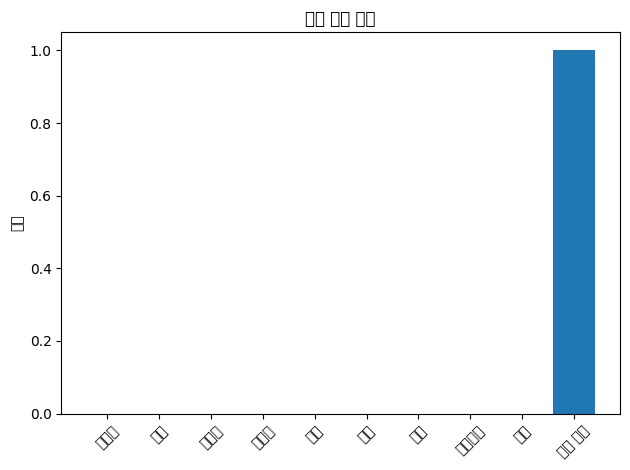

In [25]:
plt.bar(range(1, 11), pred[0])
plt.xticks(range(1, 11), classes, rotation=45)
plt.ylabel('확률')
plt.title('예측 확률 분포')
plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
예측 클래스 :  바지


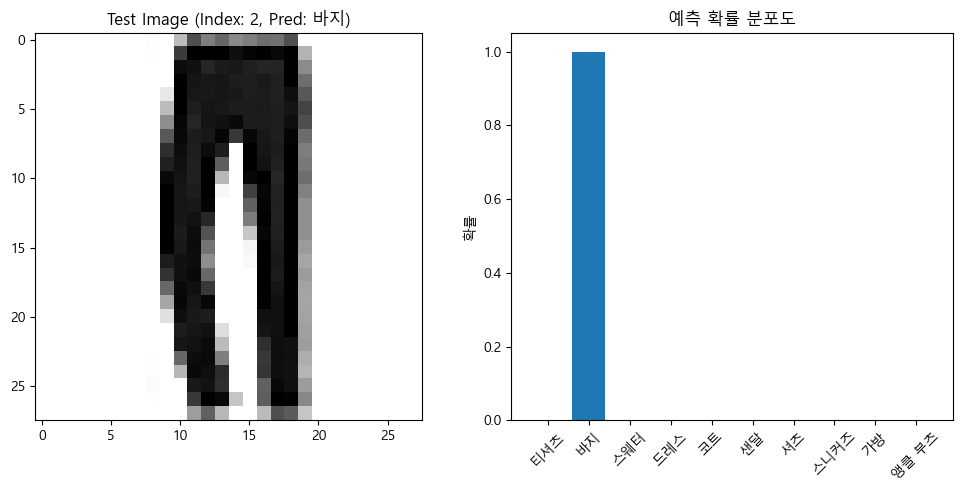

In [26]:
import matplotlib.pyplot as plt
import platform


# OS에 따라 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # macOS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')


# 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False


# 예측기
def predict_plot(n):
    preds = model.predict(test_scaled[n:n+1])
    print("예측 클래스 : ", classes[np.argmax(preds)])


    # 시각화
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))


    axes[0].imshow(test_scaled[n], cmap='gray_r')
    axes[0].set_title(f"Test Image (Index: {n}, Pred: {classes[np.argmax(preds)]})")


    axes[1].bar(range(1, 11), preds[0])
    axes[1].set_xticks(range(1, 11))
    axes[1].set_xticklabels(classes, rotation=45)
    axes[1].set_ylabel('확률')
    axes[1].set_title('예측 확률 분포도')


    plt.tight_layout()
    plt.show()


predict_plot(2)